# 15 — Equity gallery (fully offline)

One equity+drawdown chart pair for every persisted portfolio line under
`data/`, plus an all-lines overlay (each line normalized to 100 at its own
active start) and a drawdown overlay. Everything here is read from local
parquet files — **no network, no LLM, no credentials**.

Line register (windows and provenance): see `workbook/SIMULATIONS.md` —
the per-run simulation register this gallery mirrors.

| Line | Window | Note |
|---|---|---|
| `static_bh_equity_2016_2026` | 2016–2026 decade | S0 in-sample showcase |
| `static_bh_equity_2014_2024` | 2014–2024 | walk-forward frame static B&H |
| `factor_equity_v1` / `_v2` | 2019–2024 stream | PIT macro-factor lines (nb13/nb14) |
| `factor_equity_ext2026` | 2019–2026 extended | PIT factor, extended window |
| `factor_nonpit_diagnostic_equity_v1` / `_ext2026` | as above | **DIAGNOSTIC CONTROL — never deployable** (non-PIT) |
| `baseline_equity_2019_2024` / `_ext2026` | stream / extended | HRP + momentum baseline (nb07) |
| `track_a_equity_2019_2024` | stream | LLM directional agent (nb09) |
| `track_a_steered_equity_2019_2024` | stream | memory-guarded Track A (nb11) |
| `track_b_equity_2019_2024` / `_ext2026` | stream / extended | MC/Nash regime allocation (nb08) |
| `sjm_crowding_derisk_equity_ext2026` | 2019–2026 extended | SJM regime × crowding de-risk overlay on the PIT factor (nb17) |

Standing framing: these are **realized simulation equity curves only** — no
forecast-accuracy claims are made or implied. Lines stored on the 2014-anchored
frame carry a flat pre-start stub; each chart below trims to the active
span (same convention as `scripts/build_tear_sheet.py`). Files missing
locally are skipped with a printed note.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

DATA = Path("..") / "data"

# (file stem, short label, is_diagnostic)
LINES = [
    ("static_bh_equity_2016_2026", "Static B&H 16-26", False),
    ("static_bh_equity_2014_2024", "Static B&H 14-24", False),
    ("factor_equity_v1", "Factor v1", False),
    ("factor_equity_v2", "Factor v2", False),
    ("factor_nonpit_diagnostic_equity_v1", "Factor non-PIT v1", True),
    ("factor_equity_ext2026", "Factor ext26", False),
    ("factor_nonpit_diagnostic_equity_ext2026", "Factor non-PIT ext26", True),
    ("baseline_equity_2019_2024", "Baseline 19-24", False),
    ("track_a_equity_2019_2024", "Track A 19-24", False),
    ("track_a_steered_equity_2019_2024", "Track A steered", False),
    ("track_b_equity_2019_2024", "Track B 19-24", False),
    ("baseline_equity_ext2026", "Baseline ext26", False),
    ("track_b_equity_ext2026", "Track B ext26", False),
    ("sjm_crowding_derisk_equity_ext2026", "SJM×crowding de-risk ext26", False),
]

DIAG_TAG = "DIAGNOSTIC CONTROL — never deployable"


def active_value(value: pd.Series) -> pd.Series:
    """Trim to the active span: last flat day before the first move onward.

    Same convention as ``scripts/build_tear_sheet.py`` — drops the flat
    pre-start stub of lines stored on the 2014-anchored frame.
    """
    moving = value[value.ne(value.iloc[0])]
    if moving.empty:
        return value
    first_move = moving.index.min()
    prior = value.index[value.index < first_move]
    start = prior.max() if len(prior) else first_move
    return value.loc[start:]


loaded: dict[str, tuple[str, bool, pd.Series]] = {}
for stem, label, diag in LINES:
    path = DATA / f"{stem}.parquet"
    if not path.exists():
        print(f"SKIPPED (not present locally): {path.name}")
        continue
    loaded[stem] = (label, diag, active_value(pd.read_parquet(path)["value"]))
print(f"{len(loaded)}/{len(LINES)} lines loaded")

14/14 lines loaded


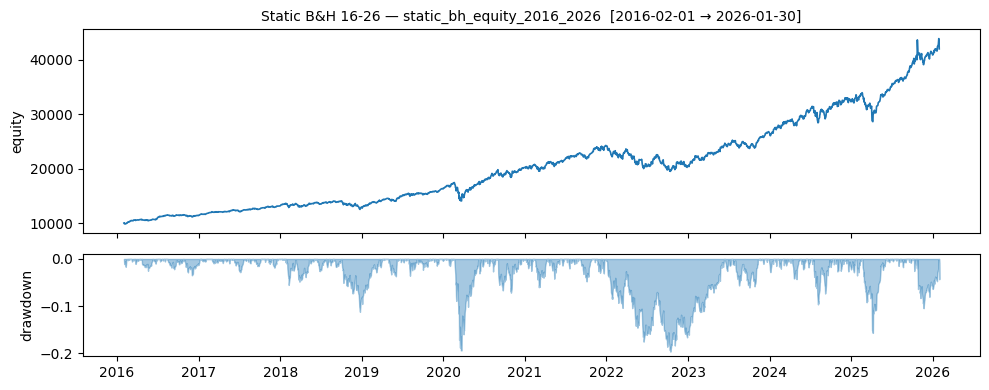

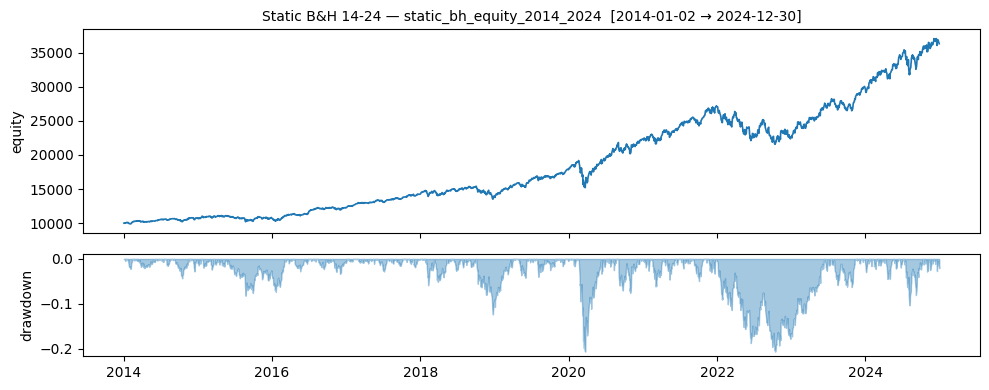

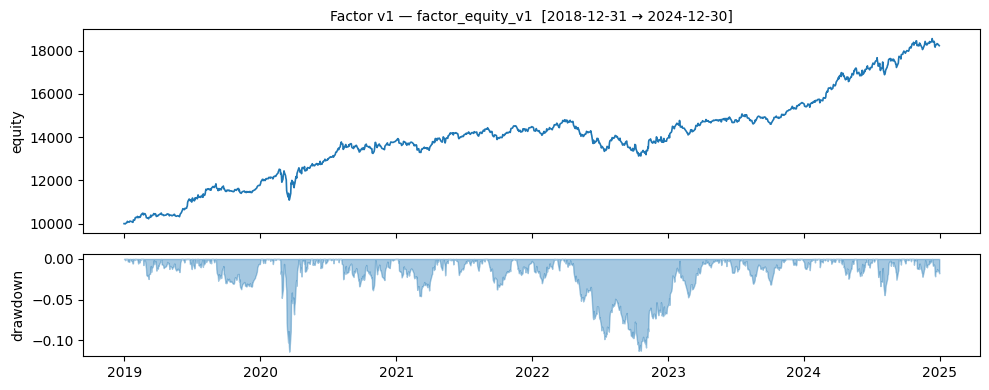

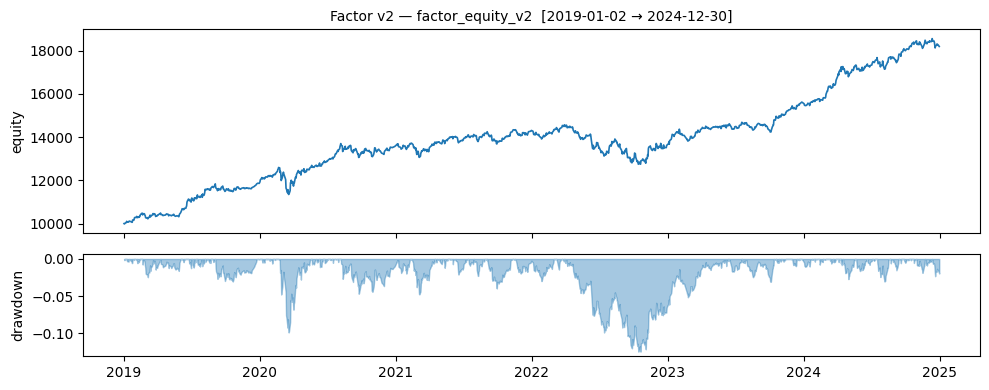

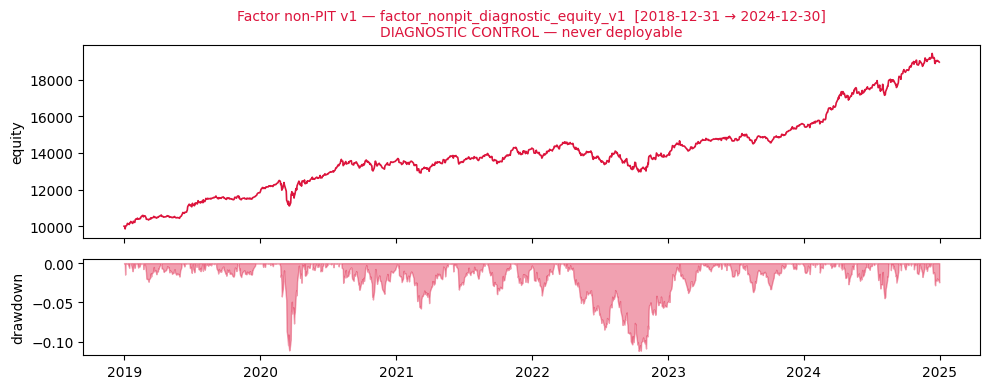

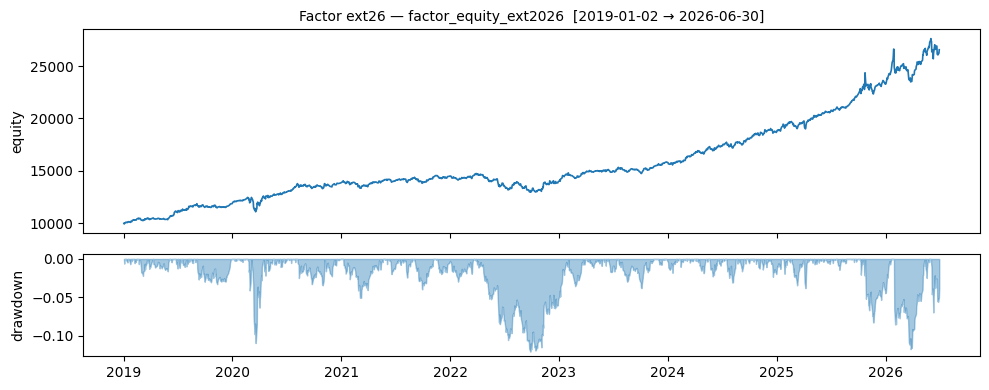

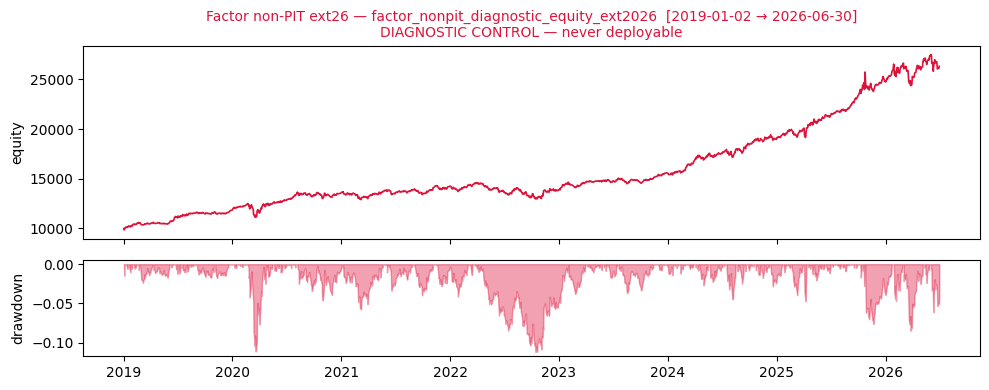

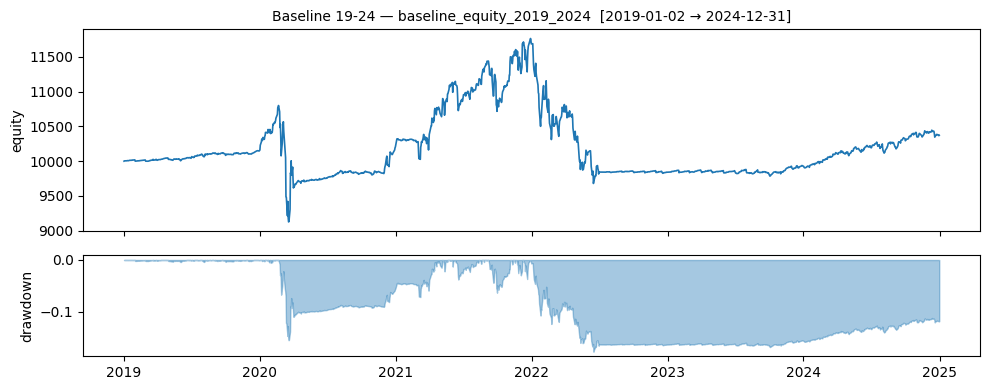

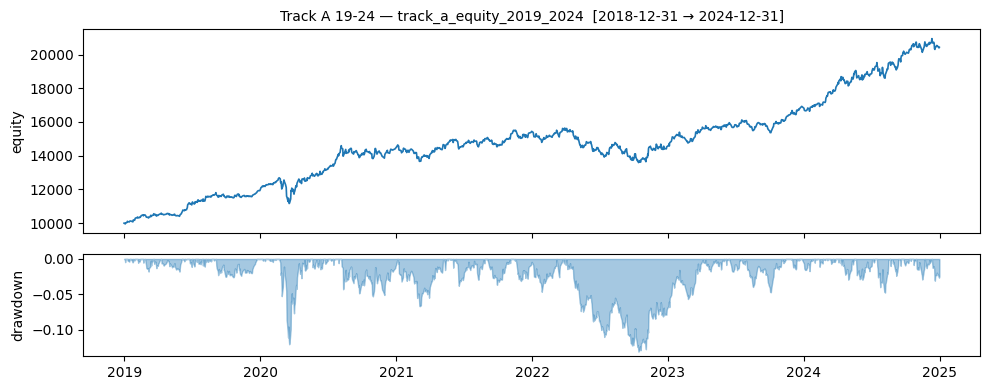

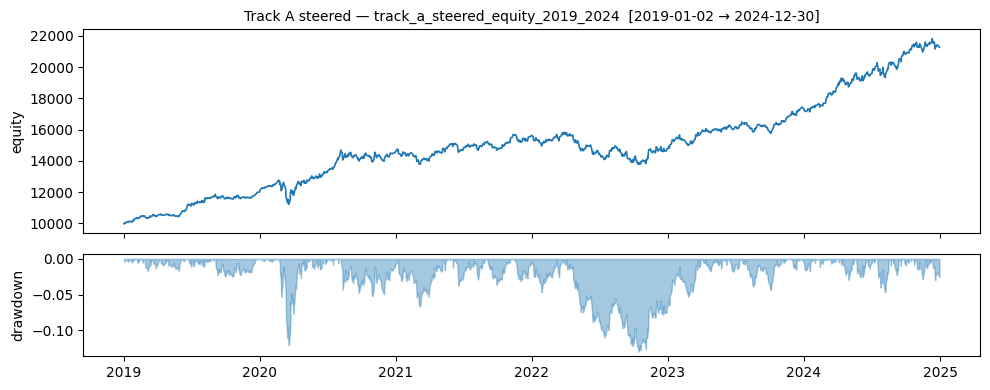

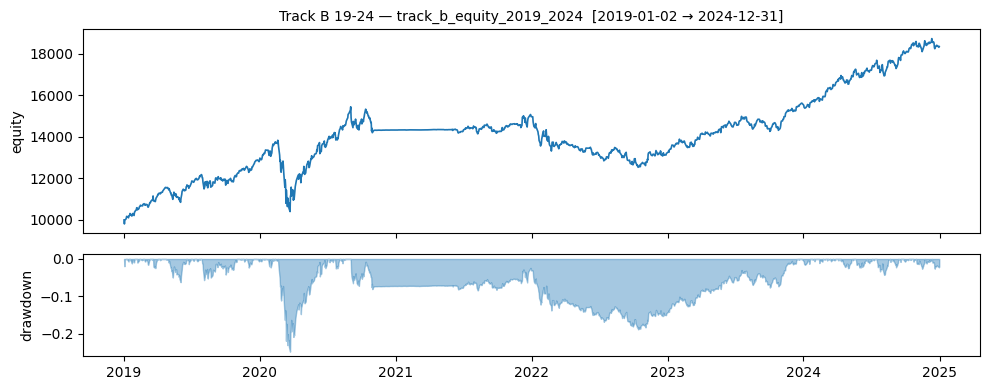

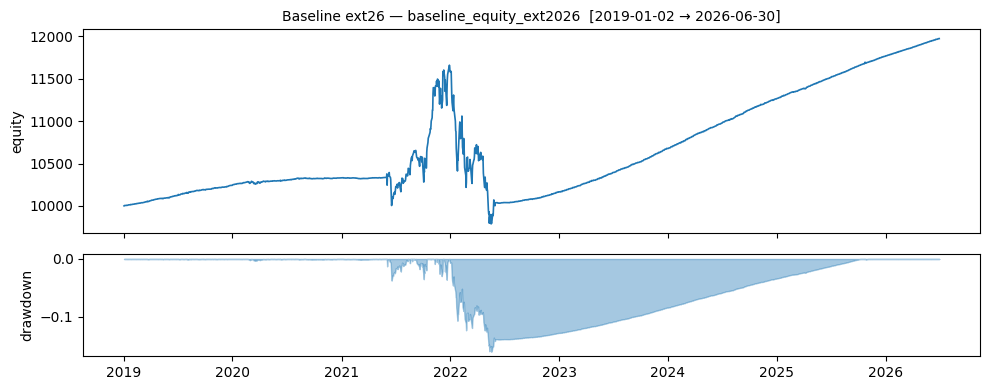

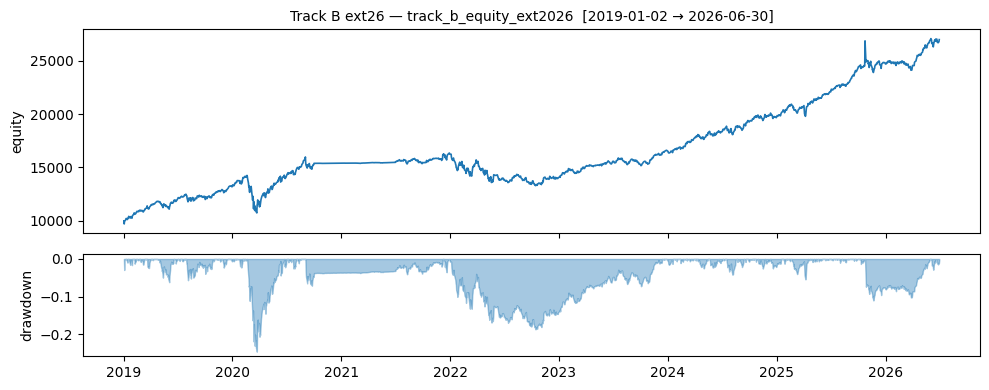

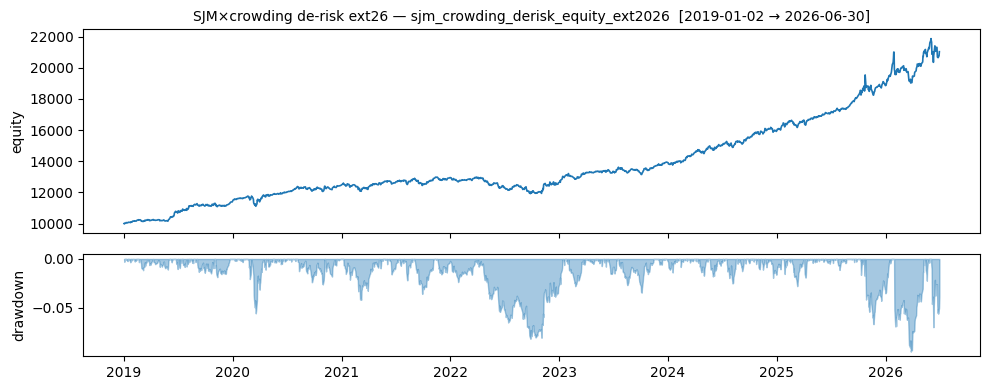

In [2]:
for stem, (label, diag, value) in loaded.items():
    dd = value / value.cummax() - 1
    title = f"{label} — {stem}  [{value.index.min():%Y-%m-%d} → {value.index.max():%Y-%m-%d}]"
    if diag:
        title += f"\n{DIAG_TAG}"
    fig, (ax_eq, ax_dd) = plt.subplots(
        2, 1, figsize=(10, 4), sharex=True,
        gridspec_kw={"height_ratios": [2, 1]},
    )
    ax_eq.plot(value.index, value, lw=1.2, color="crimson" if diag else "C0")
    ax_eq.set_title(title, fontsize=10, color="crimson" if diag else "black")
    ax_eq.set_ylabel("equity")
    ax_dd.fill_between(dd.index, dd, 0, color="crimson" if diag else "C0", alpha=0.4)
    ax_dd.set_ylabel("drawdown")
    fig.tight_layout()
    plt.show()


## Overlays — indicative only, windows differ

Each line is normalized to 100 at its own active start, so the overlay
compares shapes, not a race: the windows differ (2016–2026 decade vs the
2019–2024 stream vs the 2019–2026 extended runs). Non-PIT diagnostic lines
are dashed red: **DIAGNOSTIC CONTROL — never deployable**.


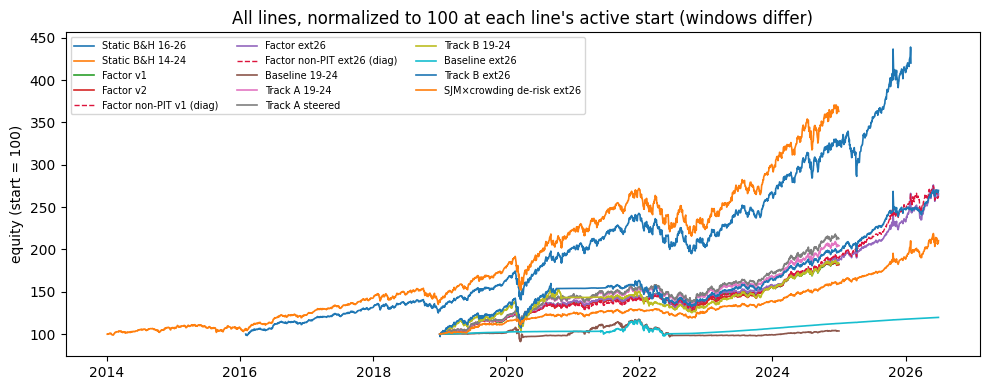

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
for stem, (label, diag, value) in loaded.items():
    norm = 100 * value / value.iloc[0]
    style = {"color": "crimson", "ls": "--", "lw": 1} if diag else {"lw": 1.2}
    ax.plot(norm.index, norm, label=f"{label} (diag)" if diag else label, **style)
ax.set_title("All lines, normalized to 100 at each line's active start (windows differ)")
ax.set_ylabel("equity (start = 100)")
ax.legend(fontsize=7, ncol=3)
fig.tight_layout()
plt.show()


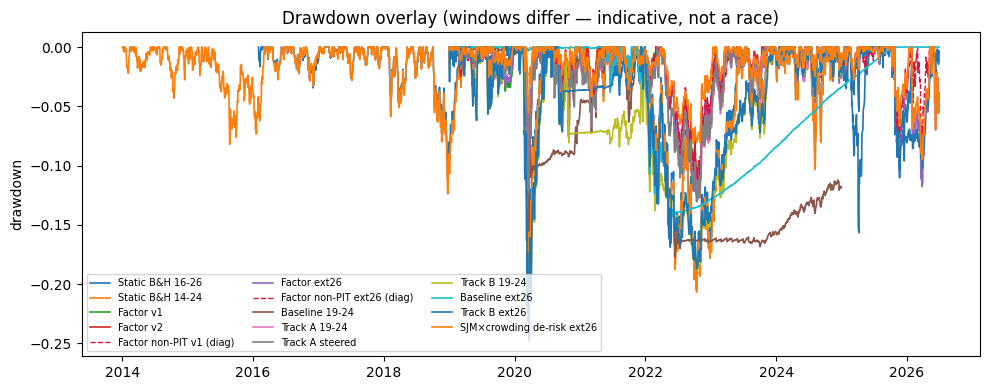

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
for stem, (label, diag, value) in loaded.items():
    dd = value / value.cummax() - 1
    style = {"color": "crimson", "ls": "--", "lw": 1} if diag else {"lw": 1.2}
    ax.plot(dd.index, dd, label=f"{label} (diag)" if diag else label, **style)
ax.set_title("Drawdown overlay (windows differ — indicative, not a race)")
ax.set_ylabel("drawdown")
ax.legend(fontsize=7, ncol=3, loc="lower left")
fig.tight_layout()
plt.show()


---

Realized simulation curves only — no forecast-accuracy claims. For the Excel
path to these same curves (the pyxll workbook build), see
`workbook/ASSESSMENT.md`; per-run provenance is in
`workbook/SIMULATIONS.md`.
